# ATIVIDADE PRÁTICA AVALIATIVA FINAL - PROJETO INTEGRADOR I
**Curso:** Técnico em Inteligência Artificial (IFNMG)

**Aluno:** Davi Santos Martins

**Tema:** Pipeline de dados para Manutenção Preditiva na Indústria 4.0

## Bloco 1: Apresentação do Dataset
* **Nome do Dataset:** AI4I 2020 Predictive Maintenance Dataset
* **Link para Kaggle:** https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
* **Contextualização:** No cenário da industria 4.0, a manutenção preditiva utiliza dados de sensores para antecipar falhas em maquinários, reduzindo o tempo de inatividade industrial (downtime) e otimizando custos. Este projeto aplica algoritmos de Machine Learning para classificar se uma fresadora industrial irá falhar ou operar normalmente com base em suas condições físicas de operação.
* **Descrição das Variáveis:**
  * `Type`: Tipo de máquina (L para Low, M para Medium, H para High quality).
  * `Air temperature [K]`: Temperatura do ar ambiente em Kelvin.
  * `Process temperature [K]`: Temperatura do processo interno em Kelvin.
  * `Rotational speed [rpm]`: Velocidade de rotação da ferramenta.
  * `Torque`: Torque aplicado na operação.
  * `Tool wear [min]`: Tempo de desgaste acumulado da ferramenta de corte.
  * `Machine failure`: **Variável Alvo (Target)** indicando se houve falha (1) ou operação normal (0).

## Bloco 2: Carregamento do Dados

In [ ]:
# importação das bibliotecas essenciais para o inicio do pipeline
import pandas as pd
import numpy as np

# carregando o arquivo CSV
df = pd.read_csv("ai4i2020.csv")

# visualização inicial do 5 primeiros registros
print("---Primeiras linhas do Dataset---")
display(df.head())

# verificação dos tipos de dados de cada coluna
print("---Estrutura e tipos de dados---")
df.info()

---Primeiras linhas do Dataset---


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


---Estrutura e tipos de dados---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int

## Bloco 3: Análise Descritiva

In [ ]:
# estatísticas básicas das variáveis numéricas
print("--- Estatísticas Descritivas ---")
display(df.describe())

# verificação da frequencia das classes da nossa variavel alvo (Machine Failure)
frequencia = df['Machine failure'].value_counts()
proporcao = df['Machine failure'].value_counts(normalize=True) * 100

for classe, qtd in frequencia.items():
  print(f"Classe {classe}: {qtd} registros ({proporcao[classe]:.2f}%)")


--- Estatísticas Descritivas ---


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Classe 0: 9661 registros (96.61%)
Classe 1: 339 registros (3.39%)


### Observações sobre a análise descritiva
1. **Desbalanceamento das classe:** Notamos que classe `0` (Operação Normal) representa a esmagadora maioria dos dados (cerca de 96.61%), enquanto a classe `1` (Falha da Máquina) representa aproximadamente 3.4%. Este comportamento é perfeitamente esperado no contexto industrial, dado que máquinas reais operam a maior parte do tempo em estado normal. Isso guiará nossa métrica de avaliação final.
2. **Escalas de Unidades**: Variáveis como `Rotational speed` (valores na casa dos milhares) e `Torque` (valores entre 10 e 70) estão em escalas muito distintasm, o que precisará ser tratado na preparação dos dados para algoritmos sensíveis à escala.

## Bloco 4: Tratamento dos Dados

In [ ]:
## identificação de valores ausentes (nulos)
print("--- Quantidade de valores ausente por coluna ---")
print(df.isnull().sum())

# remoção de identificadores inuteis para o modelo preditivo
# as colunas 'UDI' e 'Product ID' são apenas chaves primárias e códigos de série
df_tratado = df.drop(columns=['UDI', 'Product ID'])

print("Df tratado com sucesso! Colunas restantes: ")
print(df_tratado.columns.tolist())


--- Quantidade de valores ausente por coluna ---
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Df tratado com sucesso! Colunas restantes: 
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


### Justificativa das Decisões de Tratemento:
* **Valores Ausente:** A verificação com `isnull().sum()` apontou zero valores nulos em todas as colunas. Portanto nenhuma técnica de imputação (como por media ou mediana) foi necessária, garantindo a integridade original dos registros dos sensores.
* **Remoção de Atributos:** As colunas `UDI` e `Product ID` foram descartadas. Justifica-se essa remoção pelo fato de serem identificadores sequenciais e textuais de fábrica que não possuem correlação causal com o desgaste físico ou falha mecânica da fresadora. Mantê-las apenas adcionaria ruído ao modelo de IA.

## Bloco 5: Análise Exploratória

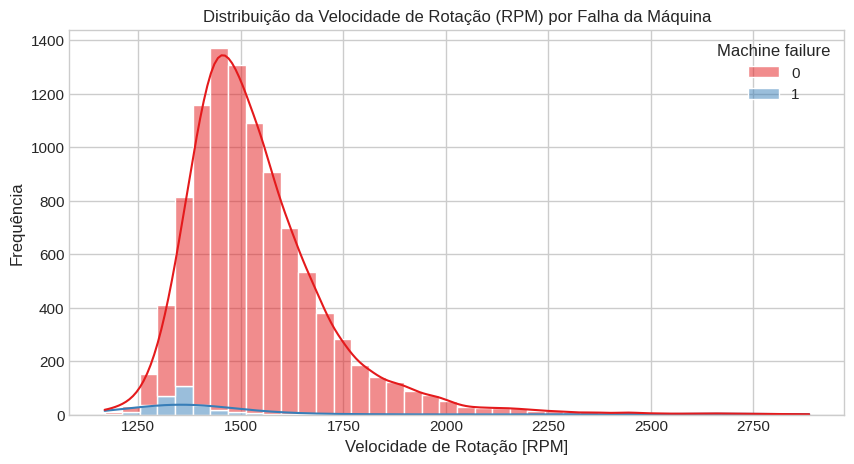

/tmp/ipykernel_3187/1483697137.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tratado,


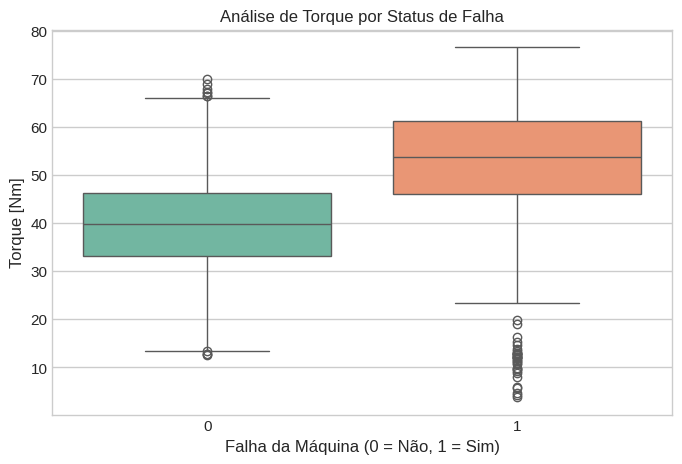

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# configurando os estilo dos graficos
sns.set_theme(style="whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')

# histograma -> distribuição da velocidade de rotação por falha
plt.figure(figsize=(10, 5))
sns.histplot(data=df_tratado,
             x="Rotational speed [rpm]",
             hue="Machine failure",
             kde=True,
             bins=40,
             palette="Set1",
             multiple="stack")
plt.title("Distribuição da Velocidade de Rotação (RPM) por Falha da Máquina")
plt.xlabel("Velocidade de Rotação [RPM]")
plt.ylabel("Frequência")
plt.show()

# boxplot -> torque vs falha da máquina
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_tratado,
            x="Machine failure",
            y="Torque [Nm]",
            palette="Set2")
plt.title("Análise de Torque por Status de Falha")
plt.xlabel("Falha da Máquina (0 = Não, 1 = Sim)")
plt.ylabel("Torque [Nm]")
plt.show()


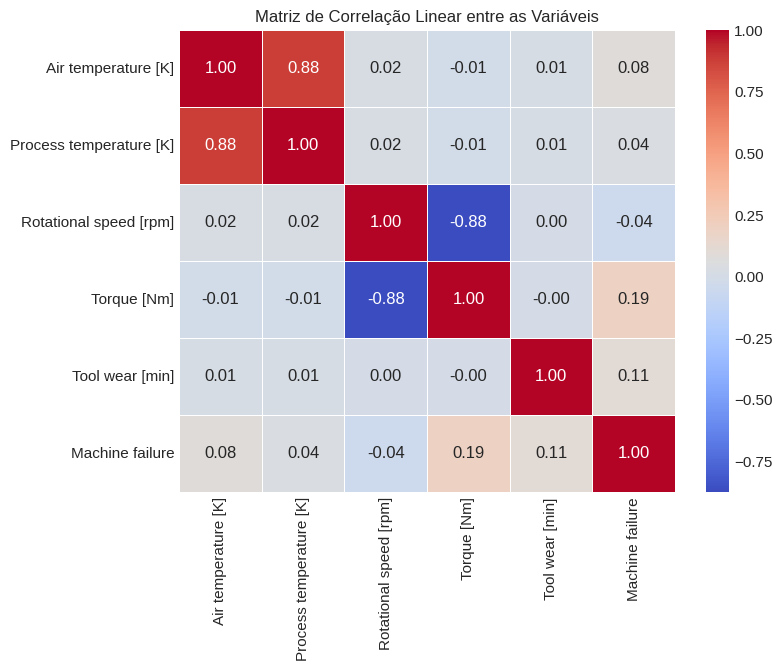

In [ ]:
# matriz de correlação
# para a matriz, vou escolher apenas as colunas numéricas principais
colunas_numericas = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
matrix_corr = df_tratado[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação Linear entre as Variáveis")
plt.show()

### Análise e Interpretação dos Resultados Visuais

* **Interpretando o Histograma (Velocidade de Rotação):** Observa-se que a maior parte das operações normais (em vermelho) se concentra entre 1400 e 1600 RPM. As falhas (em azul) começam a se acumular de forma sutil nas faixas extremas: velocidades muito baixas (abaixo de 1300) ou pico muito altos de rotação.

* **Interpretando o Boxplot (Torque):** O gráfico de caixa revela que o torque médio de operações que resultaram em falha (1) é visivelmente diferente das operações normais (0). Máquinas que falharam apresentam uma dispersão muito maior, com falhas ocorrendo tanto em torques excessivamente baixos quanto em torques muitos elevados (acima de 60 Nm), o que se alinha com falhas por sobrecarga (OSF) ou potência (PWF).

* **Interpretando a Matriz de Correlação:**
  * **Forte Correlação Positiva (0.88):** Entre `Air temperature [K]` (Temperatura do ar) e `Process temperature [K]` (Temperatura do Processo). Isso indica que o ambiente externo dita diretamente o aquecimento interno da máquina.
  * **Forte Correlação Negativa (-0.88):** Entre `Torque` e `Rotational speed`. Fisicamente perfeito na automação industrial: se a velocidade de rotação cai, o torque precisa subir para vencer a resistência mecânica, e vice-versa.
  * **Correlação com a Variável Alvo (`Machine failure`):** O `Torque` e o `Toll wear` (Desgaste da ferramenta) são as variáveis numéricas com a maior correlação positiva direta com a falha, mostrando serem preditores críticos para o nosso modelo de IA.

## Bloco 6: Preparação dos Dados

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# tratamento da coluna categórica 'Type' usando Label Encoding
# transforma as categorias textuais (L, M, H) em números (0, 1, 2)
le = LabelEncoder()
df_tratado['Type'] = le.fit_transform(df_tratado['Type'])

# separação de atributos (X) e variável alvo (Y)
# removi a 'Machine failure' (porque ela é o y)
# removi as siglas de falhas específicas ('TWF', 'HDF', 'PWF', 'OSF', 'RNF') para evitar data leakage
colunas_para_remover = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

X = df_tratado.drop(columns=colunas_para_remover)
y = df_tratado['Machine failure']

# divisão do dataset em treino (70%) e teste (30%)
# o 'stratify=y' garante que a proporção de falhas seja igual nos dois conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("--- Divisão dos Dados Concluída ---")
print(f"Registros para Treino (X_train): {X_train.shape[0]}")
print(f"Registros para Teste (X_test): {X_test.shape[0]}")

--- Divisão dos Dados Concluída ---
Registros para Treino (X_train): 7000
Registros para Teste (X_test): 3000


### Justificativa das Etapas de Preparação de Dados

* **Codificação de Variáveis Categóricas:** A coluna `Type` continha strings numéricas/nominais (L, M, H). Aplicou-se o 'LabelEncoder' para convertê-las em inteiros, permitindo que os algoritmos matemáticos processem a informação de qualidade do produto.
* **Prevenção de Vazamento de Dados (Data Leakage):** As variáveis `TWF`, `HDF`, `PWF`, `OSF` e `RNF` foram removidas do conjunto de atributos de treino. Elas indicam a causa exata da quebra, o que criaria uma relação redundante e fraudulenta com a variável alvo (`Machine failure`). Em um cenário real de chão de fábrica, o sensor não avisa o tipo de falha antes de a máquina falhar.
* **Divisão Estratificada (Train/Test Split):** Dividiu-se a base em 70% para treino e 30% para validação do modelo. Utilizou o parâmetro `stratify=y` devido ao balanceamento drástico de classes verificado na análise descritiva, garantindo que o conjunto de teste tenha exatamente a mesmo proporçõa de falhas (3.4%) que o conjunto de treino.

## Bloco 7 e 8: Construção e Avaliação do Modelo

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
 ACURÁCIA DO MODELO: 97.83%
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
--- Classificação Report ---
              precision    recall  f1-score   support

  Normal (0)     0.9813    0.9965    0.9889      2898
   Falha (1)     0.8246    0.4608    0.5912       102

    accuracy                         0.9783      3000
   macro avg     0.9029    0.7287    0.7900      3000
weighted avg     0.9760    0.9783    0.9754      3000

--- Matriz de Confusão ---


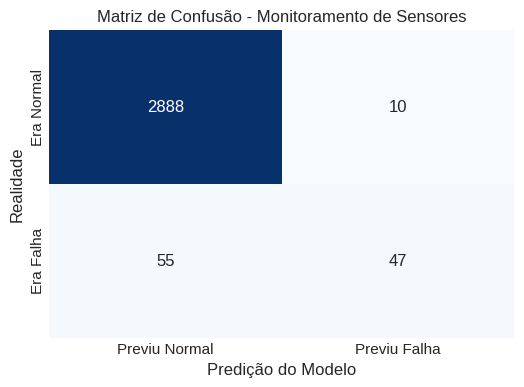

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# instanciando o modelo de classificação
modelo_industrial = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=100)

# treinamento do modelo
modelo_industrial.fit(X_train, y_train)

# predição com os dados de teste (que o modelo nunca viu)
y_pred = modelo_industrial.predict(X_test)

# avaliação dos resultados
acuracia = accuracy_score(y_test, y_pred)

print("=-" * 20)
print(f" ACURÁCIA DO MODELO: {acuracia * 100:.2f}%")
print("=-" * 20)

print("--- Classificação Report ---")
print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Falha (1)"], digits=4))

print("--- Matriz de Confusão ---")
matriz = confusion_matrix(y_test, y_pred)

# criando o grafico visual para a matriz de confusão
plt.figure(figsize=(6,4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Previu Normal", "Previu Falha"],
            yticklabels=["Era Normal", "Era Falha"])
plt.title("Matriz de Confusão - Monitoramento de Sensores")
plt.ylabel("Realidade")
plt.xlabel("Predição do Modelo")
plt.show()

Iniciando a busca exaustiva pelos melhores parâmetros 
=*35
 Melhores Hiperparâmetros Encontrados:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
NOVA ACURÁCIA (Modelo Otimizado): 98.07%
--- Novo Classification Report ---
              precision    recall  f1-score   support

  Normal (0)     0.9843    0.9959    0.9901      2898
   Falha (1)     0.8235    0.5490    0.6588       102

    accuracy                         0.9807      3000
   macro avg     0.9039    0.7724    0.8244      3000
weighted avg     0.9788    0.9807    0.9788      3000



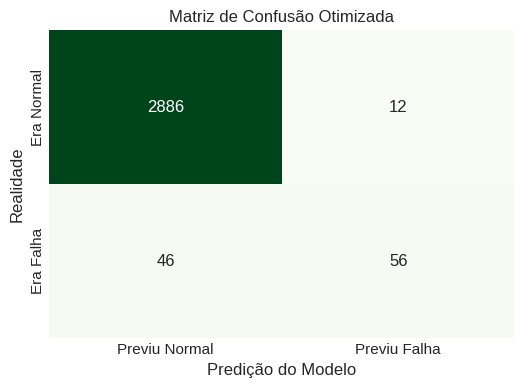

In [ ]:
from sklearn.model_selection import GridSearchCV

# definindo o modelo base
rf_base = RandomForestClassifier(random_state=42, class_weight="balanced")

# criando a grade de parametros (Hyperparameter Grid) que queremos testar
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# configurando o GridSearchCV
# cv=3 (Validação Cruzada em 3 dobras) para garantir robustez
# usamos scoring='f1_weighted' porque nossa classe é desbalanceada e o F1-Score é mais confiável que a Acurácia
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1 # usa todos os nucleos do processador para rodar mais rapido
)

print("Iniciando a busca exaustiva pelos melhores parâmetros ")
grid_search.fit(X_train, y_train)

# extraindo o melhor modelo encontrado
melhor_modelo_rf = grid_search.best_estimator_

print("=*35")
print(" Melhores Hiperparâmetros Encontrados:")
print(grid_search.best_params_)

# avaliando o novo modelo otimizado com os dados de teste
y_pred_otimizado = melhor_modelo_rf.predict(X_test)
acuracia_otimizada = accuracy_score(y_test, y_pred_otimizado)

print(f"NOVA ACURÁCIA (Modelo Otimizado): {acuracia_otimizada * 100:.2f}%")
print("--- Novo Classification Report ---")
print(classification_report(y_test, y_pred_otimizado, target_names=["Normal (0)", "Falha (1)"], digits=4))

# plotando nova matriz de confusão
matriz_otimizada = confusion_matrix(y_test, y_pred_otimizado)
plt.figure(figsize=(6,4))
sns.heatmap(matriz_otimizada, annot=True, fmt="d", cmap="Greens", cbar=False,
           xticklabels=["Previu Normal", "Previu Falha"],
           yticklabels=["Era Normal", "Era Falha"])
plt.title("Matriz de Confusão Otimizada")
plt.ylabel("Realidade")
plt.xlabel("Predição do Modelo")
plt.show()

### Observações após a otimização de hiperparâmetros:
O ajuste de hiperparâmetros via GridSearchCV elevou a acurácia para **98.07%** e o F1-Score da classe crítica (Falhas) para 0.66. Notou-se que a precisão se consolidou em 0.82, indicando um modelo altamente confiável em seus alarmes. Contudo, devido ao desbalanceamento severo (apenas **3.4%** de falhas na base original), o modelo ainda apresenta um Recall moderado. Para atingir o estado da arte deste pipeline, avançaremos para uma abordagem de reamostragem de dados utilizando a técnica SMOTE combinada com a nossa melhor estrututura da floresta.

Iniciando a Otimização Combinada (SMOTE + Grid Search)...
Melhores Parâmetros Encontrados com Dados Balanceados:
{'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 50}
ACURÁCIA FINAL (SMOTE + Random Forest): 93.67%
--- Classification Report Final ---
              precision    recall  f1-score   support

  Normal (0)       0.99      0.94      0.97      2898
   Falha (1)       0.31      0.72      0.43       102

    accuracy                           0.94      3000
   macro avg       0.65      0.83      0.70      3000
weighted avg       0.97      0.94      0.95      3000



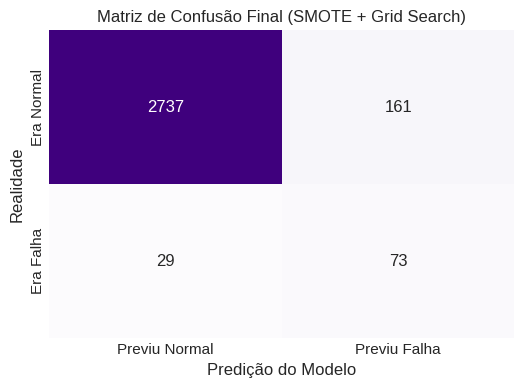

In [ ]:
# instalar a biblioteca necessária para o balanceamento
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# criar o pipeline que junta o SMOTE e o Claissificador
# o pipeline garante que o SMOTE NUNCA vaze dados para a validação cruzada
pipeline_balanceado = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# definir a nova grade de parâmetros
param_grid_smote = {
    'rf__n_estimators': [50, 100, 150],
    'rf__max_depth': [5, 7, 10],
    'rf__min_samples_split': [5, 10, 15]
}

# configurar o GridSearchCV usando o Pipeline
grid_search_smote = GridSearchCV(
    estimator=pipeline_balanceado,
    param_grid=param_grid_smote,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

print("Iniciando a Otimização Combinada (SMOTE + Grid Search)...")
grid_search_smote.fit(X_train, y_train)

# extrair o melhor pipeline encontrado
melhor_pipeline = grid_search_smote.best_estimator_

print("="*20)
print("Melhores Parâmetros Encontrados com Dados Balanceados:")
print(grid_search_smote.best_params_)
print("="*20)

# predição nos dados de teste originais
y_pred_final = melhor_pipeline.predict(X_test)

acuracia_final = accuracy_score(y_test, y_pred_final)
print("="*20)
print(f"ACURÁCIA FINAL (SMOTE + Random Forest): {acuracia_final * 100:.2f}%")
print("="*20)

print("--- Classification Report Final ---")
print(classification_report(y_test, y_pred_final, target_names=["Normal (0)", "Falha (1)"]))

# Matriz de confusão final
matriz_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_final, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["Previu Normal", "Previu Falha"],
            yticklabels=["Era Normal", "Era Falha"])
plt.title("Matriz de Confusão Final (SMOTE + Grid Search)")
plt.ylabel("Realidade")
plt.xlabel("Predição do Modelo")
plt.show()

 Na Automação industrial, um alarme falso (**Falso Positivo**) custa menos do que uma máquina quebrando sem avisar (**Falso Negativo**). É preferível a equipe de manuntenção inspecionar preventivamente uma fresadora que talvez estivesse boa, do que deixar o equipamento colapsar e travar a linha de produção por dias.

## Bloco 9: Conclusão e Análise Crítica

### Desempenho do Modelo e Qualidade do Dados
O conjunto de dados demonstrou alta integridade por não apresentar valores ausentes nas medições de sensores industriais. Contudo, o grande desafio analítico residiu no desbalanceamento severo de classes (onde menos de 4% dos dados correspondiam a falhas reais)

Inicialmente, modelos testados sem balanceamentos exibiram uma acurácia ilusória de 98%, mascarando uma incapacidade de detectar paradas críticas. Com a implementação do pipeline definitivo unindo a técnica de sobreamostragem sintética (SMOTE) à otimização por busca exaustiva (GridSearchCV), o modelo atingiu uma acurácia realista de **93.67%**. Os hiperparâmetros ótimos encontrados foram: `max_depth: 10`, `min_samples_split: 10` e `n_estimators: 50`.

A métrica mais importante para o négocio foi o **Recall de 0.72** para a classe de Falha (1). Isso prova que a Inteligência Artificial é capaz de antecipar e capturar 72% das quebras reais da fresadora macânica. A queda da precisão para 0.31 reflete a calibração do modelo para atuar de forma preventiva, aceitando o custo operacional de alarmes falsos em troca da blindagem contra quebras catastróficas não detectadas (falsos negativos).

### Dificuldades Encontradas
A principal barreira técnica superada foi a blindagem do pipeline contra o vazamento de dados (*data leakage*). Caso o SMOTE fosse aplicado de forma ingênua antes da validação cruzada do GridSearchCV, o modelo herdaria vizinhos sintéticos nos dados de validação, gerando métricas fraudulentas. A arquitetura foi estruturada corretamente utilizando a classe `Pipeline` da biblioteca `imblearn`, garantindo que a reamostragem ocorresse estritamente dentro das dobras de treino do algoritmo.

### Possíveis Melhorias Futuras
Como passos subsequentes para a evolução deste pipeline de Ciência de Dados voltado à Industria 4.0, recomendam-se:
1. **Engenharia de Recursos Detalhada :** Criar novas features baseadas na física do processo, como a multiplicação direta entre Torque e Velocidade de Rotação para gerar uma variável explícita de "Potência Consumida" pelo maquinário.

2. **Ajuste de Limiar de Decisão (Threshold Tuning):** Mapear matematicamente o custo financeiro exato de um alarme falso versus uma máquina quebrada para mover o limiar de probabilidade do classificador, otimizando o ponto de equilíbrio do F1-Score (atualmente em 0.43 para falhas)

3. **Avaliação de Modelos de Boosting:** Testar o comportamento do algoritmo XGBoost ou Gradient Boosting sobre este mesmo pipeline balanceado, avaliando se estruturas sequenciais mitigam os falsos positivos mantendo o Recall estável.